<a href="https://colab.research.google.com/github/agungdaus/data-science-2026/blob/main/Pertemuan5_Agung_Firdaus__240401010258.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#info

---




```
NAMA  : AGUNG FIRDAUS

NIM   : 240401010258

KELAS : IF403
```





In [ ]:
# ── TEMPLATE DASHBOARD VISUALISASI STATIS ────────────────────────────
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

In [ ]:
# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('tips') # ganti sesuai pilihan
print(df.shape, df.dtypes)
print(df.describe().round(2))

(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_918/634801251.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


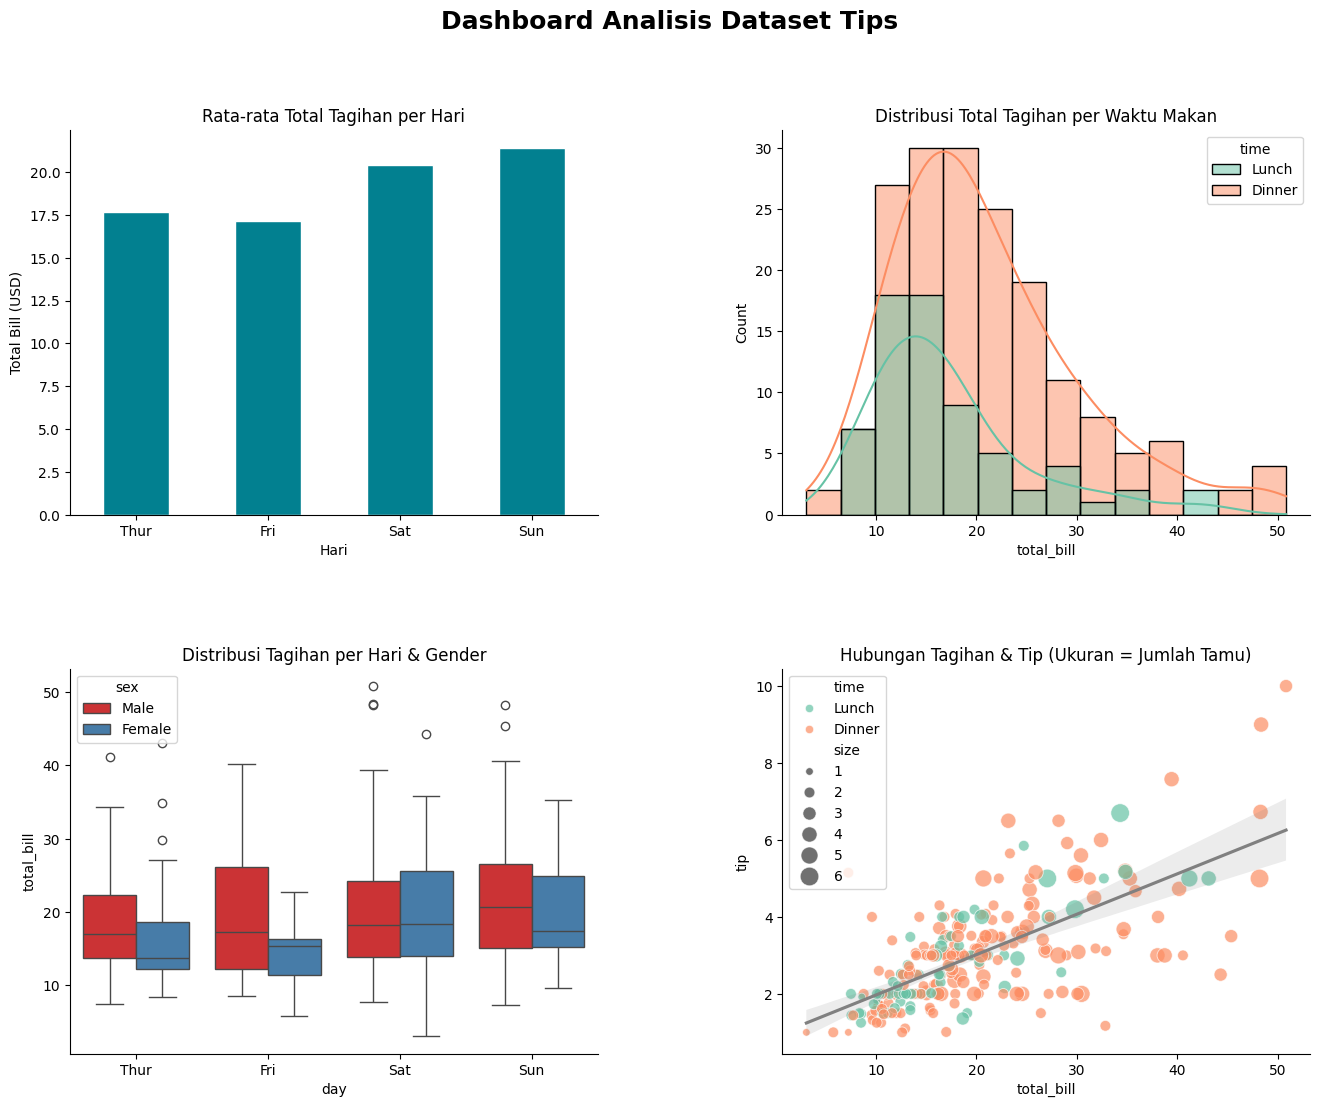

In [ ]:
# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips',
 fontsize=18, fontweight='bold', y=0.98)
# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
 hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah
# ── 3. GRAFIK 1: Bar Chart ─────────────────────────────────────────────
avg_by_day = df.groupby('day')['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090',
 edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)
# ── 4. GRAFIK 2: Histogram + KDE ───────────────────────────────────────
sns.histplot(data=df, x='total_bill', hue='time',
 kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)
# ── 5. GRAFIK 3: Boxplot ───────────────────────────────────────────────
sns.boxplot(data=df, x='day', y='total_bill',
 hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)
# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
sns.scatterplot(data=df, x='total_bill', y='tip',
 hue='time', size='size', sizes=(30,180),
palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
 scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

In [ ]:
# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

<Figure size 640x480 with 0 Axes>

Dashboard tersimpan sebagai dashboard_tips.png


# 📊 Data Storytelling: Dashboard Analisis Tips

---

## 1️⃣ Bar Chart — Rata-rata Total Tagihan per Hari

**🔍 What?**
Rata-rata tagihan tertinggi terjadi di hari **Minggu (~$21)** diikuti **Sabtu (~$20)**,
sementara Jumat memiliki rata-rata terendah (~$17).
Perbedaan antara hari terendah dan tertinggi sekitar **$4**.

**💡 So What?**
Pola ini menunjukkan bahwa **akhir pekan secara konsisten menghasilkan tagihan lebih besar**
dibanding hari kerja. Selisih $4 per meja jika dikalikan puluhan transaksi
berdampak signifikan terhadap total revenue harian.

**🚀 Now What?**
Perlu investigasi lebih lanjut: apakah tagihan lebih tinggi di weekend karena
**jumlah tamu per meja lebih banyak**, atau karena **pilihan menu yang lebih mahal**?
Ini menentukan strategi promosi yang tepat — fokus ke grup besar atau upselling menu premium.

---

## 2️⃣ Histogram + KDE — Distribusi Tagihan per Waktu Makan

**🔍 What?**
Distribusi **Dinner** jauh lebih banyak dan menyebar luas dari ~$10 hingga $50
dengan puncak di sekitar **$15–20**. Distribusi **Lunch** lebih sempit dan
terkonsentrasi di **$10–20** dengan frekuensi jauh lebih sedikit.
Kedua distribusi bersifat **right-skewed**, menandakan ada pelanggan dengan tagihan sangat tinggi.

**💡 So What?**
Dinner bukan hanya lebih ramai, tapi juga memiliki **variasi tagihan yang jauh lebih besar** —
segmen pelanggan Dinner lebih beragam, mulai dari yang budget hingga high-spender.
Lunch cenderung didominasi pelanggan dengan tagihan seragam dan lebih rendah.

**🚀 Now What?**
Strategi menu sebaiknya **dibedakan antara Lunch dan Dinner**.
Lunch difokuskan pada paket hemat cepat saji, sementara Dinner menawarkan
menu premium atau paket grup untuk mengkapitalisasi high-spender ($40–$50).

---

## 3️⃣ Boxplot — Distribusi Tagihan per Hari & Gender

**🔍 What?**
Di semua hari, **Male secara konsisten memiliki median tagihan lebih tinggi** dibanding Female.
Perbedaan paling mencolok di **Jumat**: median Male (~$18) vs Female (~$14).
Terdapat outlier signifikan di Kamis (Male ~$40) dan Sabtu (Female ~$44, Male ~$48).

**💡 So What?**
Perbedaan tagihan berdasarkan gender mengindikasikan **pola belanja yang berbeda** —
pria cenderung memesan lebih banyak atau memilih item lebih mahal.
Outlier di $40–$50 menunjukkan adanya **pelanggan high-value di kedua gender**.

**🚀 Now What?**
Perlu analisis lebih dalam: apakah perbedaan ini dipengaruhi **siapa yang membayar bill
di meja campuran**, atau memang preferensi menu berbeda?
Temuan ini penting sebelum merancang campaign pemasaran berbasis segmen pelanggan.

---

## 4️⃣ Scatter Plot — Hubungan Tagihan & Tip

**🔍 What?**
Terdapat **korelasi positif yang jelas** antara total tagihan dan tip.
Garis regresi menunjukkan tren naik dari tip ~$1–2 pada tagihan $5–10,
hingga tip ~$6–7 pada tagihan $40–50. Titik berukuran besar (meja 5–6 orang)
mayoritas berada di kuadran kanan atas, dan **Dinner** mendominasi tagihan tinggi.

**💡 So What?**
Hubungan linear ini mengkonfirmasi bahwa **meningkatkan nilai tagihan per meja
secara langsung meningkatkan tip** — artinya upselling menguntungkan restoran
sekaligus memotivasi pelayan. Meja besar adalah target prioritas.

**🚀 Now What?**
Restoran bisa merancang **strategi upselling terstruktur** seperti menu rekomendasi
untuk meja besar atau paket sharing untuk grup. Perlu juga dihitung
**tip rate (tip/total_bill)** untuk melihat apakah Lunch atau Dinner
yang secara proporsional lebih dermawan.
"""

#KESIMPULAN

---
Pertemuan kelima tentang Visualisasi Data mempelajari tentang mengomunikasikan data secara visual agar temuan mudah dipahami, bukan sekadar menghitung angka, tapi menyajikannya dengan grafik yang efektif menggunakan Matplotlib dan Seaborn.